In [1]:
import json
import io
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from dataset import LSMDataset, collate_fn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
from dataset import make_splits
from augmentations import build_train_augments

aug = build_train_augments()

In [3]:
splits = json.loads(Path("splits.json").read_text())

train_ds = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=splits["train"], augment=aug)
val_ds   = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=splits["val"])
test_ds  = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=splits["test"])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn)

NUM_CLASSES = train_ds.num_classes
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Clases: {NUM_CLASSES}")

LSMDataset cargado: 1467 muestras | 249 clases | normalize=True | augment=on
LSMDataset cargado: 491 muestras | 249 clases | normalize=True | augment=off
LSMDataset cargado: 489 muestras | 249 clases | normalize=True | augment=off
Train: 1467 | Val: 491 | Test: 489
Clases: 249


In [4]:
train_ids_s, val_ids_s, test_ids_s = make_splits(
    "../corpus_LSM_esp/lsm_dataset.parquet",
    strategy="stratified",
    seed=42,
)

train_ds_s = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=train_ids_s)
val_ds_s   = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=val_ids_s)

train_loader_s = DataLoader(train_ds_s, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader_s   = DataLoader(val_ds_s,   batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_ds_s)} | Val: {len(val_ds_s)} | Test: {len(test_ids_s)}")


───────────────────────────────────────────────────────
Split: stratified
───────────────────────────────────────────────────────
  Total  : 2447
  Train  :  1643  (67.1%)
  Val    :   402  (16.4%)
  Test   :   402  (16.4%)

  ✓  Sin overlaps de video_id entre splits

  Clases en train : 249
  Clases en val   : 249
  Clases en test  : 249

  Señadores en train : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11']
  Señadores en val   : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11']
  Señadores en test  : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11']
  ⚠  Señadores compartidos entre splits: {'02', '10', '09', '04', '07', '11', '05', '01', '08', '06', '03'}
───────────────────────────────────────────────────────
LSMDataset cargado: 1643 muestras | 249 clases | normalize=True | augment=off
LSMDataset cargado: 402 muestras | 249 clases | normalize=True | augment=off
Train: 1643 | Val: 402 | Test: 402


In [5]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        hidden_size: int = 256,
        num_layers:  int = 2,
        dropout:     float = 0.3,
        num_classes: int = 249,
    ):
        super().__init__()

        # Solo usamos x, y → 133 * 2 = 266 features por frame
        # El score no es confianza [0,1] en este dataset, lo descartamos
        input_size = 133 * 2

        self.input_proj = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size    = 256,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, keypoints: torch.Tensor, padding_mask: torch.Tensor) -> torch.Tensor:
        B, T, K, F = keypoints.shape   # ahora F=2
        x = keypoints.reshape(B, T, K * F)

        mask_f = padding_mask.unsqueeze(-1).float()  # (B, T, 1)

        # Normalizar x,y por separado usando estadísticas del batch
        # (solo sobre frames válidos para no contaminar con padding)
        x_valid = x * mask_f                         # ceros en padding

        # Media y std por muestra (más estable que min/max)
        n_valid = mask_f.sum(dim=1).clamp(min=1)     # (B, 1)
        mean    = x_valid.sum(dim=1, keepdim=True) / n_valid.unsqueeze(-1)  # (B,1,266)

        diff    = (x - mean) * mask_f
        std     = (diff.pow(2).sum(dim=1, keepdim=True) / n_valid.unsqueeze(-1)).sqrt().clamp(min=1e-6)

        x = (x - mean) / std                         # z-score por muestra
        x = x * mask_f                               # re-enmascarar padding

        x   = self.input_proj(x)                     # (B, T, 256)
        out, _ = self.lstm(x)                        # (B, T, hidden*2)

        # Mean pooling solo frames válidos
        out = (out * mask_f).sum(dim=1) / n_valid    # (B, hidden*2)

        return self.classifier(out)                  # (B, num_classes)

model = BiLSTMClassifier(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")

# Verificar que el forward funciona y produce logits razonables
with torch.no_grad():
    batch = next(iter(train_loader))
    logits = model(batch["keypoints"].to(DEVICE), batch["padding_mask"].to(DEVICE))
    print(f"Logits shape: {logits.shape}")
    print(f"Logits std (debería ser > 0.01 si hay señal): {logits.std().item():.4f}")
    probs = torch.softmax(logits, dim=1)
    print(f"Max prob media por muestra (uniforme=0.004, señal>0.01): {probs.max(dim=1).values.mean().item():.4f}")

Parámetros entrenables: 2,894,841
Logits shape: torch.Size([32, 249])
Logits std (debería ser > 0.01 si hay señal): 0.3177
Max prob media por muestra (uniforme=0.004, señal>0.01): 0.0094


In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        kpts = batch["keypoints"].to(DEVICE)
        mask = batch["padding_mask"].to(DEVICE)
        lbls = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(kpts, mask)
        loss   = criterion(logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * lbls.size(0)
        correct    += (logits.argmax(dim=1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        kpts = batch["keypoints"].to(DEVICE)
        mask = batch["padding_mask"].to(DEVICE)
        lbls = batch["labels"].to(DEVICE)

        logits = model(kpts, mask)
        loss   = criterion(logits, lbls)

        total_loss += loss.item() * lbls.size(0)
        correct    += (logits.argmax(dim=1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / total, correct / total

In [7]:
EPOCHS    = 50
LR        = 3e-4
PATIENCE  = 10   # early stopping

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = eval_epoch(model,   val_loader,             criterion)

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"] .append(tr_acc)
    history["val_loss"]  .append(va_loss)
    history["val_acc"]   .append(va_acc)

    print(f"Epoch {epoch:>3}/{EPOCHS} | "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f}  acc {va_acc:.3f}")

    # Early stopping + guardar mejor modelo
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_lstm.pt")
        print("Mejor modelo guardado")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping en epoch {epoch}")
            break

Epoch   1/50 | train loss 5.5660  acc 0.001 | val loss 5.5228  acc 0.004
Mejor modelo guardado
Epoch   2/50 | train loss 5.5341  acc 0.004 | val loss 5.5236  acc 0.004
Epoch   3/50 | train loss 5.5248  acc 0.002 | val loss 5.5193  acc 0.004
Mejor modelo guardado
Epoch   4/50 | train loss 5.5252  acc 0.003 | val loss 5.5177  acc 0.006
Mejor modelo guardado
Epoch   5/50 | train loss 5.5238  acc 0.004 | val loss 5.5179  acc 0.004
Epoch   6/50 | train loss 5.5209  acc 0.005 | val loss 5.5202  acc 0.004
Epoch   7/50 | train loss 5.5191  acc 0.005 | val loss 5.5179  acc 0.006
Epoch   8/50 | train loss 5.5206  acc 0.004 | val loss 5.5178  acc 0.004
Epoch   9/50 | train loss 5.5187  acc 0.005 | val loss 5.5177  acc 0.006
Mejor modelo guardado
Epoch  10/50 | train loss 5.5201  acc 0.005 | val loss 5.5177  acc 0.006
Epoch  11/50 | train loss 5.5184  acc 0.007 | val loss 5.5187  acc 0.004
Epoch  12/50 | train loss 5.5173  acc 0.003 | val loss 5.5199  acc 0.006
Epoch  13/50 | train loss 5.5192  ac

In [28]:
model_s = BiLSTMClassifier(num_classes=NUM_CLASSES).to(DEVICE)
opt_s   = torch.optim.AdamW(model_s.parameters(), lr=3e-4, weight_decay=1e-3)
crit_s  = nn.CrossEntropyLoss(label_smoothing=0.1)
sched_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s, T_max=50)

PATIENCE = 10
best_val_loss_s  = float("inf")
epochs_no_improve_s = 0
history_s = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_s, train_loader_s, opt_s, crit_s)
    va_loss, va_acc = eval_epoch(model_s, val_loader_s,   crit_s)
    sched_s.step()

    history_s["train_loss"].append(tr_loss)
    history_s["train_acc"] .append(tr_acc)
    history_s["val_loss"]  .append(va_loss)
    history_s["val_acc"]   .append(va_acc)

    print(f"Epoch {epoch:>3}/50 | "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f}  acc {va_acc:.3f}")

    if va_loss < best_val_loss_s:
        best_val_loss_s = va_loss
        epochs_no_improve_s = 0
        torch.save(model_s.state_dict(), "best_lstm_stratified.pt")
        print("Mejor modelo guardado")
    else:
        epochs_no_improve_s += 1
        if epochs_no_improve_s >= PATIENCE:
            print(f"  ⏹  Early stopping en epoch {epoch}")
            break

Epoch   1/50 | train loss 5.5659  acc 0.001 | val loss 5.5231  acc 0.007
Mejor modelo guardado
Epoch   2/50 | train loss 5.5368  acc 0.002 | val loss 5.5205  acc 0.002
Mejor modelo guardado
Epoch   3/50 | train loss 5.5258  acc 0.004 | val loss 5.5194  acc 0.005
Mejor modelo guardado
Epoch   4/50 | train loss 5.5213  acc 0.004 | val loss 5.5219  acc 0.005
Epoch   5/50 | train loss 5.5066  acc 0.004 | val loss 5.4626  acc 0.005
Mejor modelo guardado
Epoch   6/50 | train loss 5.4237  acc 0.004 | val loss 5.3741  acc 0.002
Mejor modelo guardado
Epoch   7/50 | train loss 5.2974  acc 0.005 | val loss 5.2185  acc 0.012
Mejor modelo guardado
Epoch   8/50 | train loss 5.1593  acc 0.014 | val loss 5.1206  acc 0.010
Mejor modelo guardado
Epoch   9/50 | train loss 5.0351  acc 0.018 | val loss 5.0381  acc 0.020
Mejor modelo guardado
Epoch  10/50 | train loss 4.8837  acc 0.030 | val loss 4.8992  acc 0.030
Mejor modelo guardado
Epoch  11/50 | train loss 4.6877  acc 0.057 | val loss 4.8212  acc 0.057

In [29]:
model_s.load_state_dict(torch.load("best_lstm_stratified.pt", map_location=DEVICE))

test_ds_s  = LSMDataset("../corpus_LSM_esp/lsm_dataset.parquet", video_ids=test_ids_s)
test_loader_s = DataLoader(test_ds_s, batch_size=32, shuffle=False, collate_fn=collate_fn)

test_loss_s, test_acc_s = eval_epoch(model_s, test_loader_s, crit_s)
print(f"Test loss: {test_loss_s:.4f}  |  Test acc: {test_acc_s:.4f}")

LSMDataset cargado: 402 muestras | 249 clases | normalize=True
Test loss: 4.4511  |  Test acc: 0.1169



=== Métricas en test ===
  top1_acc    : 0.1169
  top5_acc    : 0.3209
  macro_f1    : 0.0964


/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/lustre/home/estudiante_27/.local/lib/python3.10/site-pac

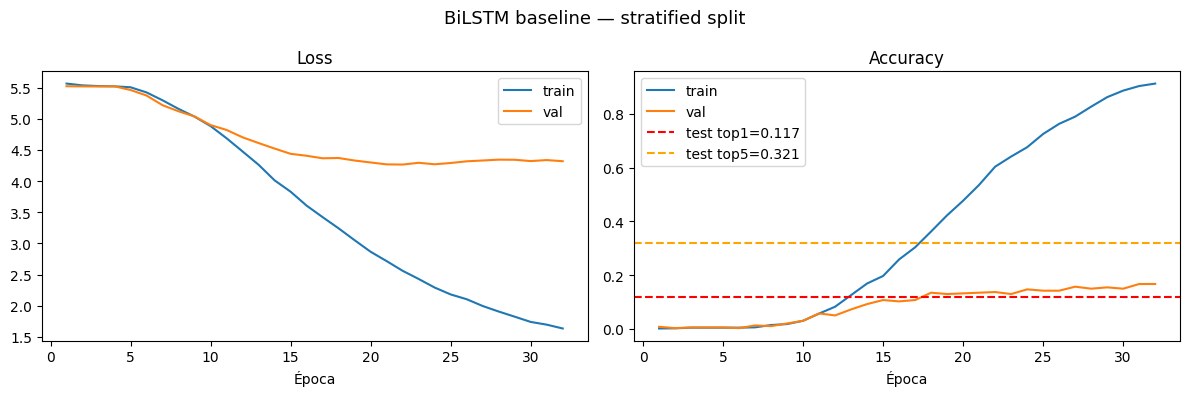

In [30]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_full(model, loader, k=5):
    model.eval()
    all_preds, all_labels = [], []
    top1 = topk = total = 0

    for batch in loader:
        kpts   = batch["keypoints"].to(DEVICE)
        mask   = batch["padding_mask"].to(DEVICE)
        lbls   = batch["labels"].to(DEVICE)
        logits = model(kpts, mask)

        top1 += (logits.argmax(dim=1) == lbls).sum().item()
        topk += (logits.topk(k, dim=1).indices == lbls.unsqueeze(1)).any(dim=1).sum().item()
        total += lbls.size(0)

        all_preds .extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())

    return {
        "top1_acc":  top1 / total,
        f"top{k}_acc": topk / total,
        "macro_f1":  f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }

metrics = evaluate_full(model_s, test_loader_s, k=5)
print("\n=== Métricas en test ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history_s["train_loss"]) + 1)

axes[0].plot(epochs_range, history_s["train_loss"], label="train")
axes[0].plot(epochs_range, history_s["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(epochs_range, history_s["train_acc"], label="train")
axes[1].plot(epochs_range, history_s["val_acc"],   label="val")
axes[1].axhline(metrics["top1_acc"], color="red", linestyle="--",
                label=f"test top1={metrics['top1_acc']:.3f}")
axes[1].axhline(metrics[f"top5_acc"], color="orange", linestyle="--",
                label=f"test top5={metrics['top5_acc']:.3f}")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.suptitle("BiLSTM baseline — stratified split", fontsize=13)
plt.tight_layout()
plt.show()

Test loss: 4.3210  |  Test acc: 0.1084


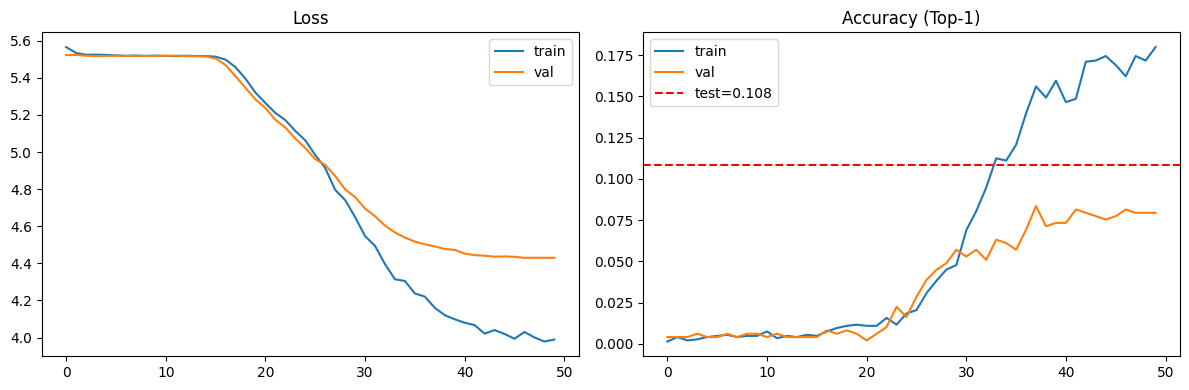

In [8]:
import matplotlib.pyplot as plt

# Cargar mejor modelo
model.load_state_dict(torch.load("best_lstm.pt", map_location=DEVICE))
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f"Test loss: {test_loss:.4f}  |  Test acc: {test_acc:.4f}")

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].axhline(test_acc, color="red", linestyle="--", label=f"test={test_acc:.3f}")
axes[1].set_title("Accuracy (Top-1)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import f1_score

@torch.no_grad()
def evaluate_full(model, loader, k=5):
    model.eval()
    all_preds, all_labels = [], []
    top1_correct = top_k_correct = total = 0

    for batch in loader:
        kpts   = batch["keypoints"].to(DEVICE)
        mask   = batch["padding_mask"].to(DEVICE)
        lbls   = batch["labels"].to(DEVICE)
        logits = model(kpts, mask)

        top1_correct  += (logits.argmax(dim=1) == lbls).sum().item()
        topk           = logits.topk(k, dim=1).indices
        top_k_correct += (topk == lbls.unsqueeze(1)).any(dim=1).sum().item()
        total         += lbls.size(0)

        all_preds .extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(lbls.cpu().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "top1_acc":  top1_correct  / total,
        f"top{k}_acc": top_k_correct / total,
        "macro_f1":  macro_f1,
    }

metrics = evaluate_full(model, test_loader, k=5)
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

  top1_acc    : 0.1084
  top5_acc    : 0.3231
  macro_f1    : 0.0720


/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/lustre/home/estudiante_27/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/lustre/home/estudiante_27/.local/lib/python3.10/site-pac